In [1]:
# Import library dasar
import os
import random
import numpy as np
import tensorflow as tf

# Import library untuk dataset dan visualisasi
import matplotlib.pyplot as plt

# Set random seed agar hasil eksperimen lebih konsisten
seed_value = 42
os.environ["PYTHONHASHSEED"] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

print("Initial setup completed. Seed has been fixed.")

Initial setup completed. Seed has been fixed.


In [2]:
# Install gdown untuk download file dari Google Drive
!pip install gdown -q

import gdown

# File ID dari link Google Drive
file_id = "1b67VYi8SuLv8ru8oFNC9ZqZBLynZ4F3V"
url = f"https://drive.google.com/uc?id={file_id}"

# Nama file output di Colab
output = "dataset_split_224.zip"

# Download dataset
gdown.download(url, output, quiet=False)

print("Dataset downloaded successfully.")

Downloading...
From: https://drive.google.com/uc?id=1b67VYi8SuLv8ru8oFNC9ZqZBLynZ4F3V
To: /content/dataset_split_224.zip
100%|██████████| 19.4M/19.4M [00:00<00:00, 136MB/s]

Dataset downloaded successfully.


In [3]:
# Extract file zip dataset
import zipfile
import shutil

EXTRACT_PATH = "/content/dataset"

# Hapus folder lama kalau ada, biar tidak bentrok
if os.path.exists(EXTRACT_PATH):
    shutil.rmtree(EXTRACT_PATH)

os.makedirs(EXTRACT_PATH, exist_ok=True)

# Extract zip
with zipfile.ZipFile("dataset_split_224.zip", "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [4]:
# Cek struktur folder dataset
for root, dirs, files in os.walk(EXTRACT_PATH):
    level = root.replace(EXTRACT_PATH, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")

    if level < 3:
        for f in files[:5]:
            print(f"{indent}  {f}")

dataset/
  train/
    AI/
      filippo-nassetti-ai-designs-spaceships-bosch-caravaggio-designboom-600.jpg
      GettyImages-1096829784-copy.jpg
      image33.jpg
      Blogs.jpg
      psychedelic-image-edited-2.png
    Real/
      HD-wallpaper-scenery-lake-nature-sky-tree-water.jpg
      Portrait-Photographers-Yousuf-Karsh-King.jpg
      7ce6zbax23_WEB_257649.jpg
      set-safari-animals-illustration-600nw-2150029883.jpg
      02-still-for-america-room-loop-superJumbo.jpg
  test/
    AI/
      1440_AI_and_animal_language_feat.jpg
      335893730_1248848252414001_2214479283759117231_n_1679724354609_1679724368314_1679724368314.jpg
      sddefault.jpg
      tp-composite-ai-art-new.jpg
      1588269690157-Screen-Shot-2020-04-30-at-20037-PM.png
    Real/
      people-pleasing_mask.jpg
      147660_1.jpg
      image16.jpeg
      1200px-Claude_Monet2C_Impression2C_soleil_levant.jpg
      sddefault.jpg
  val/
    AI/
      ai-art-prompt-8.png
      wp-image-940-16849365973x2.jpg
      elizabe

In [5]:
# Path utama dataset
DATASET_PATH = "/content/dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Train path:", TRAIN_DIR)
print("Validation path:", VAL_DIR)
print("Test path:", TEST_DIR)

Train path: /content/dataset/train
Validation path: /content/dataset/val
Test path: /content/dataset/test


In [6]:
# Cek jumlah gambar pada setiap folder
for split_name, split_dir in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}.items():
    print(f"\n{split_name} Set")

    for class_name in os.listdir(split_dir):
        class_path = os.path.join(split_dir, class_name)

        if os.path.isdir(class_path):
            total_images = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
            ])
            print(f"{class_name}: {total_images} images")


Train Set
AI: 303 images
Real: 303 images

Validation Set
AI: 65 images
Real: 65 images

Test Set
AI: 66 images
Real: 66 images


In [7]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Pengaturan standar eksperimen
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load training dataset
train_dataset = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

# Load validation dataset
val_dataset = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

# Load test dataset
test_dataset = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Datasets loaded successfully.")
print("Class names:", train_dataset.class_names)

Found 606 files belonging to 2 classes.
Found 129 files belonging to 2 classes.
Found 131 files belonging to 2 classes.
Datasets loaded successfully.
Class names: ['AI', 'Real']


In [8]:
# Optimasi pipeline dataset agar proses training lebih efisien
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized successfully.")

Dataset pipeline optimized successfully.


In [9]:
# Import layer dan model yang dibutuhkan
from tensorflow.keras import layers, models

# Build Custom CNN model
model = models.Sequential([
    # Input gambar ukuran 224x224 dengan 3 channel warna RGB
    layers.Input(shape=(224, 224, 3)),

    # Rescale pixel dari 0-255 menjadi 0-1
    layers.Rescaling(1./255),

    # Convolution block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Convolution block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Convolution block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Convolution block 4
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Mengubah feature map menjadi vektor
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Dropout untuk mengurangi overfitting
    layers.Dropout(0.5),

    # Output layer untuk binary classification
    layers.Dense(1, activation="sigmoid")
])

print("Custom CNN model built successfully.")

Custom CNN model built successfully.


In [10]:
# Menampilkan ringkasan arsitektur model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,811,201 (25.98 MB)

 Trainable params: 6,811,201 (25.98 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile model dengan pengaturan standar yang disamakan
LEARNING_RATE = 0.001

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [12]:
# Train model CNN
EPOCHS = 20

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

print("Model training completed.")

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 516ms/step - accuracy: 0.4950 - loss: 0.7155 - precision: 0.4946 - recall: 0.4554 - val_accuracy: 0.5659 - val_loss: 0.6923 - val_precision: 0.5506 - val_recall: 0.7538
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.5050 - loss: 0.6927 - precision: 0.5040 - recall: 0.6271 - val_accuracy: 0.5039 - val_loss: 0.6893 - val_precision: 0.5039 - val_recall: 1.0000
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5050 - loss: 0.6919 - precision: 0.5027 - recall: 0.9109 - val_accuracy: 0.6202 - val_loss: 0.6876 - val_precision: 0.6176 - val_recall: 0.6462
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6122 - loss: 0.6764 - precision: 0.6189 - recall: 0.5842 - val_accuracy: 0.6434 - val_loss: 0.6588 - val_precision: 0.6022 - val_recall: 0.8615
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5990 - loss: 0.6676 - precision: 0.5877 - recall: 0.6634 - val_accuracy: 0.6434 - val_loss: 0.665

In [13]:
# Menyimpan history training ke file CSV
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df.insert(0, "epoch", range(1, len(history_df) + 1))
history_df.to_csv("cnn_training_history.csv", index=False)

print("CNN training history saved successfully.")

CNN training history saved successfully.


In [14]:
# Evaluasi model pada test dataset
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_dataset)

# Menghitung F1-score
if (test_precision + test_recall) == 0:
    test_f1 = 0
else:
    test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)

print("Test evaluation completed.")
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print(f"Test F1-Score  : {test_f1:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step - accuracy: 0.6489 - loss: 1.5546 - precision: 0.6515 - recall: 0.6515
Test evaluation completed.
Test Loss      : 1.5546
Test Accuracy  : 0.6489
Test Precision : 0.6515
Test Recall    : 0.6515
Test F1-Score  : 0.6515


In [15]:
# Menyimpan hasil evaluasi test ke file CSV
import pandas as pd

test_metrics = {
    "model": ["Custom CNN"],
    "test_loss": [test_loss],
    "test_accuracy": [test_accuracy],
    "test_precision": [test_precision],
    "test_recall": [test_recall],
    "test_f1_score": [test_f1]
}

test_metrics_df = pd.DataFrame(test_metrics)
test_metrics_df.to_csv("cnn_test_metrics.csv", index=False)

print("CNN test metrics saved successfully.")

CNN test metrics saved successfully.


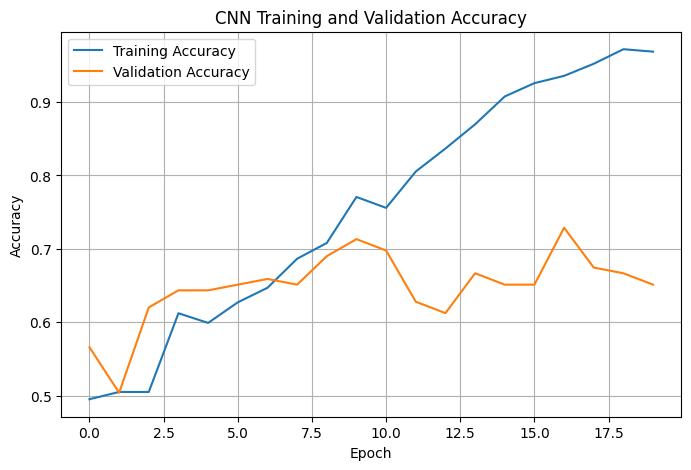

Accuracy graph displayed successfully.


In [16]:
# Membuat grafik training accuracy dan validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print("Accuracy graph displayed successfully.")

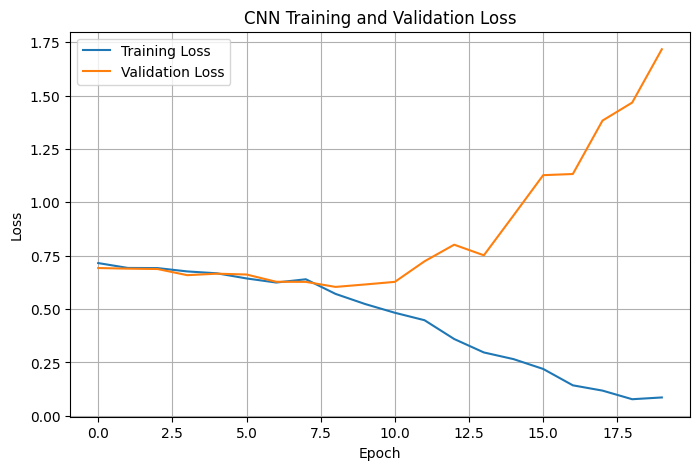

Loss graph displayed successfully.


In [17]:
# Membuat grafik training loss dan validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

print("Loss graph displayed successfully.")

In [18]:
# Import library untuk classification report dan confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Nama class sesuai urutan class dataset
class_names = ["AI", "Real"]

# Menyimpan label asli dan hasil prediksi
y_true = []
y_pred = []

# Melakukan prediksi pada test dataset
for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = (predictions >= 0.5).astype(int).flatten()

    y_pred.extend(predicted_labels)
    y_true.extend(labels.numpy().astype(int).flatten())

# Mengubah list menjadi array
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Prediction results generated successfully.")

Prediction results generated successfully.


In [19]:
# Menampilkan classification report
print("--- CNN Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

--- CNN Classification Report ---
              precision    recall  f1-score   support

          AI       0.65      0.65      0.65        65
        Real       0.65      0.65      0.65        66

    accuracy                           0.65       131
   macro avg       0.65      0.65      0.65       131
weighted avg       0.65      0.65      0.65       131



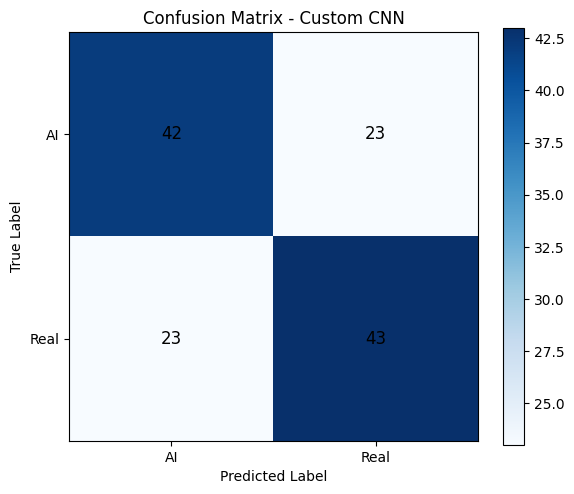

Confusion matrix displayed successfully.


In [20]:
# Membuat confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

# Visualisasi confusion matrix yang lebih rapi
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - Custom CNN")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# Threshold untuk warna teks
threshold = cm.max() / 2

# Menampilkan angka di dalam kotak
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            color="black" if cm[i, j] > threshold else "black",
            fontsize=12,
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Confusion matrix displayed successfully.")

In [21]:
# Simpan model CNN
model.save("cnn_custom_model.h5")
model.save("cnn_custom_model.keras")

print("Model saved successfully.")

Model saved successfully.
